# Deep learning for time series: RNN, GRU, LSTM and friends

Every model in this series so far has shared one worldview: write down a small parametric story about how the series evolves — a smoothed level, an ARMA polynomial, a state space recursion — and estimate a handful of parameters, one series at a time. This episode switches paradigms. A **recurrent neural network (RNN)** makes almost no assumptions about the shape of the dynamics; instead it maintains a **hidden state** — a vector of numbers that acts as a running memory — and *learns* how to update that memory from the data itself. No stationarity tests, no order selection, no seasonal differencing: the network is handed raw (well, rescaled) history and figures out the rest.

That freedom has a price, and the price is the real subject of this notebook. Plain RNNs forget: the mathematics of backpropagation through time makes gradients decay (or explode) exponentially with sequence length, so a vanilla recurrent cell cannot learn dependencies more than a few dozen steps back. The whole modern zoo — **GRU**, **LSTM**, encoder–decoder architectures, bidirectional wrappers — exists to route around that single mathematical fact.

The plan is a ladder, each rung adding exactly one ingredient:

1. **Groundwork** — turn a flat temperature series into the 3D tensors Keras expects, split it *chronologically before scaling* (a leakage trap we will make a point of dodging), and fix two naive baselines that every network must beat.
2. **A controlled detour** — a twenty-line NumPy experiment that shows the vanishing/exploding gradient problem with your own eyes, so the gates that follow are a solution to a problem you have actually seen.
3. **SimpleRNN → stacked RNN → GRU → LSTM** — the core family, fitted with identical scaffolding so the architectures can be compared line by line.
4. **Multi-step forecasting three ways** — recursive, direct multi-output, and a proper encoder–decoder (seq2seq), with a per-horizon error curve that shows *why* the strategy matters.
5. **Covariates and a bidirectional LSTM** — the multivariate finale, plus a serious word of warning about bidirectionality and temporal causality.

Everything runs on a small real dataset (ten years of daily minimum temperatures in Melbourne — 3,650 observations) in a few minutes on an ordinary laptop; on an Apple silicon Mac, the models train on the machine's built-in GPU.

# Setup

One grouped imports cell, one configuration cell, as always.

In [1]:
# Standard library imports
import os
import warnings

# choose the numerical engine BEFORE keras is imported — this line must come first
os.environ['KERAS_BACKEND'] = 'torch'

# Third-party imports: core data
import numpy as np
import pandas as pd

# Third-party imports: deep learning (Keras 3 on the PyTorch backend)
import torch
import keras
from keras.models import Sequential
from keras.layers import (Input, Dense, SimpleRNN, GRU, LSTM,
                          Bidirectional, RepeatVector, TimeDistributed)
from keras.callbacks import EarlyStopping

# Third-party imports: preprocessing & metrics
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Third-party imports: visualization
import matplotlib.pyplot as plt

# Configuration & settings
warnings.simplefilter(action='ignore', category=FutureWarning)

print(f'keras {keras.__version__}, backend: {keras.backend.backend()}')

keras 3.15.0, backend: torch


Walking through the imports. **`numpy`** (`np`) and **`pandas`** (`pd`) are the usual data plumbing; **`matplotlib.pyplot`** (`plt`) draws everything.

The deep learning block deserves a note, because the Keras API has moved and a lot of tutorial code out there is now obsolete. Since version 3, **Keras** is a standalone, *multi-backend* library again: you write `import keras` and `from keras.layers import ...` directly, rather than the older `from tensorflow.keras.models import ...` spelling you will still see in most blog posts (it survives as a compatibility alias, but new code should not use it). Multi-backend means Keras is the modeling *language* while a separate numerical engine — TensorFlow, **PyTorch**, or JAX — does the tensor arithmetic underneath, and one environment variable swaps the engine without touching a line of model code. The gotcha is the *ordering*: `os.environ['KERAS_BACKEND'] = 'torch'` must be set **before** `import keras`, because Keras reads it exactly once, at import time. Set it afterwards and it is silently ignored.

Why PyTorch here? Hardware. The torch backend can drive the GPU built into every Apple silicon Mac through **MPS** (Metal Performance Shaders) out of the box — TensorFlow's Mac GPU story requires a separate plugin — so this notebook trains on the laptop's own accelerator with no extra setup. (The same backend reaches NVIDIA GPUs through CUDA on other machines; nothing below would change.) We import `torch` itself for exactly one job — asking what hardware exists. Everything else talks to Keras. From it we take **`Sequential`** (the simplest way to define a model: a plain list of layers, data flowing top to bottom), the three recurrent cell types this episode is about (**`SimpleRNN`**, **`GRU`**, **`LSTM`**), the **`Dense`** fully-connected layer that turns a hidden state into a forecast, **`Input`** to declare the shape of incoming data, and three structural layers we will need for the advanced architectures: **`Bidirectional`** (a wrapper that runs a recurrent layer in both time directions), **`RepeatVector`** and **`TimeDistributed`** (the two building blocks of an encoder–decoder). **`EarlyStopping`** is a *callback* — a hook into the training loop — that halts training when the validation loss stops improving.

From scikit-learn we take **`MinMaxScaler`**, because neural networks want inputs in a small, consistent range, and the two error metrics we have used all series long. The closing `print` is a deliberate sanity check: if it does not say `backend: torch`, the environment variable arrived too late (typically because Keras was already imported earlier in the session — restart the kernel and run this cell first).

In [2]:
# general settings
class CFG:
    data_folder = './data/'
    graph_folder = './graphs/'
    img_dim1 = 16
    img_dim2 = 6
    SEED = 42
    LOOK_BACK = 30              # input window: days of history the network sees
    HORIZON = 14                # multi-step task: days predicted at once
    UNITS = 32                  # hidden units per recurrent layer
    EPOCHS = 30                 # maximum passes over the training set
    BATCH_SIZE = 32             # windows per gradient update
    CUTOFF_DATE = '1989-01-01'  # chronological train/validation boundary

# display style
plt.style.use("seaborn-v0_8")
plt.rcParams["figure.figsize"] = (CFG.img_dim1, CFG.img_dim2)

# reproducibility: seeds Python, NumPy and the deep learning backend in one call
keras.utils.set_random_seed(CFG.SEED)

The usual `CFG` namespace, with the episode-specific knobs. **`LOOK_BACK = 30`** is the length of the sliding input window: every prediction the network makes will be based on the previous thirty days of temperatures. **`HORIZON = 14`** is the multi-step task we tackle later — predict two weeks in one go. **`UNITS = 32`** sets the width of the hidden state vector, i.e. how many numbers the network's "memory" holds; more units mean more capacity and more parameters. **`EPOCHS = 30`** is a *ceiling*, not a target — early stopping will usually halt training well before it. **`BATCH_SIZE = 32`** means gradients are computed on 32 windows at a time, a standard compromise between noisy single-sample updates and slow full-dataset ones. **`CUTOFF_DATE`** puts the last two years of data (1989–1990) into a validation set the models never train on.

One line to flag: **`keras.utils.set_random_seed(CFG.SEED)`** replaces the old ritual of separately seeding `random`, `numpy` and `tensorflow` — one call seeds all three. Neural network training is far more randomness-sensitive than anything earlier in this series (random weight initialization, random batch shuffling), so without this line every rerun of the notebook would produce different numbers.

In [3]:
# hardware: use the Apple silicon GPU when there is one, plain CPU otherwise
DEVICE = 'mps' if torch.backends.mps.is_available() else 'cpu'
print(f'models will be created on: {DEVICE}')

models will be created on: mps


One new setup ritual for this episode: hardware. Deep learning is the first topic in this series where an accelerator genuinely matters — recurrent networks train through thousands of small matrix multiplications, exactly the workload GPUs were built for. **`torch.backends.mps.is_available()`** is true on Apple silicon Macs, where the M-series chip's integrated GPU is exposed through Metal Performance Shaders; `'cpu'` is the fallback — the notebook runs correctly either way, the accelerator only changes *how fast*.

The `DEVICE` string is how we make placement *explicit*: every model below is built inside a **`with keras.device(DEVICE):`** block — a backend-agnostic Keras context manager that pins the model's weights, and therefore its training arithmetic, to the chosen device. (Keras would usually find the accelerator on its own; the explicit block turns an invisible default into a visible, greppable line of code, and makes it trivial to force `'cpu'` for a fair timing comparison — or to swap in `'cuda'` on a machine with an NVIDIA card.) One footnote for reproducibility accounting: GPU floating-point arithmetic reorders reductions non-deterministically, so exact metric values can wobble in the last decimals between reruns even with the seed pinned. The rankings and the story are stable; the third decimal is not.

# Utils

Four small helpers so the modeling cells below read as short declarative calls: the metrics scorecard, the windowing function that is the real workhorse of the notebook, a callbacks factory, and two plotting wrappers.

In [4]:
def forecast_metrics(y_true, y_pred):
    """Return MAE and RMSE between two aligned arrays, rounded for display."""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return {'MAE': float(np.round(mae, 3)), 'RMSE': float(np.round(rmse, 3))}

The same scorecard as every previous episode: **MAE** (mean absolute error — the typical miss, in the units of the data, here degrees Celsius) and **RMSE** (root mean squared error — same units, but squaring makes it punish large misses disproportionately). Both come from scikit-learn; we round and cast to plain `float` so the dictionaries print cleanly. Every model in this notebook, from the naive baseline to the bidirectional LSTM, will be judged by this one function, which is what makes the closing comparison table honest.

In [5]:
def make_windows(values, look_back, look_ahead=1, target_col=0):
    """Slice a (n_obs, n_features) array into supervised windows.

    Returns X of shape [n_windows, look_back, n_features],
            y of shape [n_windows, look_ahead],
            target_idx: row index (into `values`) of each window's first target.
    """
    X, y, target_idx = [], [], []
    for i in range(len(values) - look_back - look_ahead + 1):
        X.append(values[i : i + look_back, :])
        y.append(values[i + look_back : i + look_back + look_ahead, target_col])
        target_idx.append(i + look_back)
    return np.array(X), np.array(y), np.array(target_idx)

`make_windows` is the single most important transformation in the notebook: it is the bridge between *time series forecasting* and *supervised learning*. A neural network does not consume a time series; it consumes (input, target) pairs. So we slide a window of length `look_back` along the series: the window's contents become one training input `X`, and the `look_ahead` values immediately after it become the target `y`. Then the window shifts one step and produces the next pair. A series of $n$ observations yields $n - \text{look\_back} - \text{look\_ahead} + 1$ overlapping examples.

The shape of `X` is the thing to internalize, because every recurrent layer in Keras demands it: a 3D tensor of **`[batch, timesteps, features]`** — how many windows, how many time steps each window spans, and how many variables are measured at each step. Our first models are univariate, so `features` is 1; the function takes a 2D `(n_obs, n_features)` array precisely so that the same helper serves the multivariate finale unchanged (`target_col` says which column is being forecast).

The third return value, `target_idx`, is a small addition you will not find in most tutorials, and it exists for one reason: **leak-free splitting**. Because windows overlap, "split the windows 80/20" is not the same as "split the *time* 80/20" — a window can straddle the boundary. By recording where each window's target lives in the original series, we can later assign every window to train or validation based on *when its target occurs*, which is the criterion that actually matters.

In [6]:
def get_callbacks(patience=5):
    early_stop = EarlyStopping(
        monitor='val_loss', min_delta=1e-4, patience=patience,
        mode='min', restore_best_weights=True, verbose=0,
    )
    return [early_stop]

Neural networks do not have a closed-form fit — training is an iterative descent, and knowing *when to stop* is part of the model. `get_callbacks` packages the one callback every model here uses. **`EarlyStopping`** watches the validation loss (`monitor='val_loss'`) after every epoch; if it fails to improve by at least `min_delta=1e-4` for `patience=5` consecutive epochs, training halts. The crucial argument is **`restore_best_weights=True`**: without it, the model you are left holding is the one from the *last* epoch — i.e. five epochs *past* the best point, already sliding into overfitting. With it, Keras rewinds to the weights from the best validation epoch. This is important! Early stopping is doing the job that information criteria (AIC/BIC) did for ARIMA: it is the guardrail against fitting the noise.

In [7]:
def plot_history(history, title='Training history'):
    plt.plot(history.history['loss'], label='train loss', linewidth=2)
    plt.plot(history.history['val_loss'], label='validation loss', color='red')
    plt.title(title)
    plt.xlabel('epoch'); plt.ylabel('loss (MSE, scaled data)')
    plt.legend(); plt.show()


def plot_forecast(y_true, y_pred, title='Forecast vs actual', n=200):
    plt.plot(y_true[:n], label='actual', linewidth=2)
    plt.plot(y_pred[:n], label='predicted', color='green', linestyle='--')
    plt.title(title)
    plt.ylabel('°C'); plt.legend(); plt.show()

Two plotting wrappers enforcing the series' visual language: observed values as the default solid line with `linewidth=2`, predictions as the green dashed line. `plot_history` shows the two loss curves whose relationship diagnoses training health — falling together is good, train falling while validation rises is overfitting. `plot_forecast` overlays predictions on actuals for the first `n=200` validation days; plotting all 728 turns the chart into an unreadable ribbon, and two hundred days is enough to judge whether the model tracks the level, the season, and the day-to-day wiggles.

# Groundwork: from a series to supervised tensors

Before any model, a sixty-second theory brief. A feedforward network assumes its inputs are unordered and independent — feed it the same thirty numbers in a different order and it has no way to know. Time series data violates that assumption by construction, and the recurrent architecture is the structural fix: process the sequence *one step at a time*, carrying along a hidden state vector $h_t$ that summarizes everything seen so far. At each step the network combines the new observation $x_t$ with the previous memory $h_{t-1}$:

$$h_t = \tanh(W_x x_t + W_h h_{t-1} + b)$$

and the final memory $h_T$ (or a projection of it) becomes the forecast. The two weight matrices are *shared across all time steps* — the network learns one update rule, applied recursively — which is what lets the same layer handle a window of length 30 or 300. The $\tanh$ squashes the hidden state into $(-1, 1)$ at every step, a detail that will come back to haunt us in the vanishing-gradient detour.

That is the whole conceptual core. The rest of this section is data engineering: load the series, split it, scale it, window it.

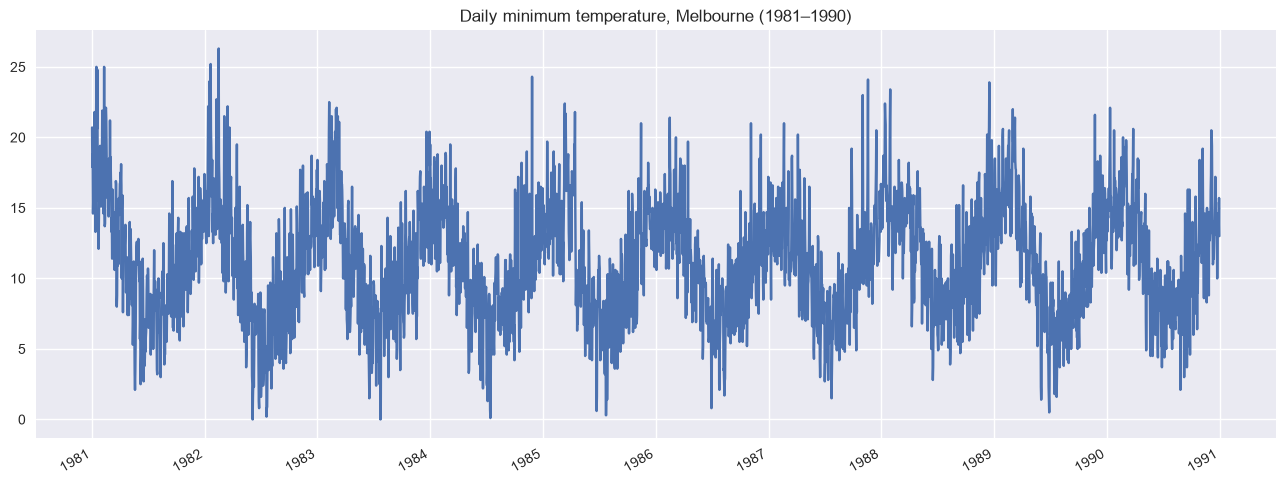

In [8]:
# load the dataset: daily minimum temperatures in Melbourne, 1981-1990
df = pd.read_csv(CFG.data_folder + 'daily-min-temperatures.csv')
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

df['Temp'].plot(xlabel='', title='Daily minimum temperature, Melbourne (1981–1990)')
plt.show()

A small classic: ten years of daily minimum temperatures recorded in Melbourne, 3,650 observations, in degrees Celsius. `pd.read_csv` loads the local copy from `CFG.data_folder`, `pd.to_datetime` converts the date strings into proper timestamps, and `set_index` (with `inplace=True`, modifying the frame in place rather than returning a copy) makes the dates the index, so pandas handles the time axis of every plot automatically.

The raw plot — always the first act of any episode — shows why this is a good teaching series for neural networks: a strong, obvious annual cycle (Southern Hemisphere summers peaking around New Year), no trend to speak of, and a thick band of day-to-day weather noise around the seasonal signal. The seasonal part is easy; the noise band is irreducible; the interesting question is how much of the in-between structure — cold snaps, warm spells, multi-day persistence — each architecture can capture. It is also deliberately *small*: big enough for a network to learn from, small enough that every model in this notebook trains in well under a minute on a CPU.

In [9]:
df.head(3)

,Temp
Date,
1981-01-01,20.7
1981-01-02,17.9
1981-01-03,18.8


The standard sanity check after data preparation: one `Temp` column, dates as the index, values that look like plausible Melbourne summer temperatures. Nothing exotic — which is the point.

In [10]:
# chronological boundary FIRST...
cutoff_idx = df.index.searchsorted(pd.Timestamp(CFG.CUTOFF_DATE))

# ...then fit the scaler on the training segment ONLY
scaler = MinMaxScaler()
scaler.fit(df[['Temp']].iloc[:cutoff_idx])
scaled = scaler.transform(df[['Temp']])

print(f'training days: {cutoff_idx}, validation days: {len(df) - cutoff_idx}')
print(f'scaler fitted on train only -> min {scaler.data_min_[0]}, max {scaler.data_max_[0]}')
print(f'validation segment after scaling: [{scaled[cutoff_idx:].min():.3f}, {scaled[cutoff_idx:].max():.3f}]')

training days: 2920, validation days: 730
scaler fitted on train only -> min 0.0, max 26.3
validation segment after scaling: [0.019, 0.840]


Two things happen here, and the *order* is the lesson.

First, the chronological boundary: `searchsorted` finds the row position of 1 January 1989, giving us eight years (2,920 days — this classic file stores tidy 365-day years, leap days absent) for training and two years (730 days) for validation. As everywhere in this series, the split is chronological — the model trains on the past and is judged on a future it has never seen — because that is the only split that simulates real forecasting.

Second, the scaling. Neural networks are sensitive to input scale: large raw values push $\tanh$ and sigmoid activations into their flat saturated zones where gradients die, so we rescale to roughly $[0,1]$ with **`MinMaxScaler`**, which maps each value to `(x - min) / (max - min)`. The trap — and it is one of the most common leaks in published deep learning forecasting code, our baseline notebook for this episode included — is calling `fit_transform` on the *full* series before splitting. Do that, and the scaler's min and max have quietly absorbed information from the validation years into every rescaled training value. The fix costs one line: **`fit` on the training segment only, then `transform` everything**. The printout shows the honest consequence: the validation segment is not guaranteed to stay inside $[0,1]$ — if 1989–1990 contained a record temperature, it would scale to a value above 1. That slight untidiness *is* what no-leakage looks like. The same discipline (split first, then let every fitted preprocessing step see only the past) was the central theme of the validation episode, and it matters more here than ever, because deep networks are expressive enough to exploit any leak you hand them.

In [11]:
X, y, target_idx = make_windows(scaled, look_back=CFG.LOOK_BACK, look_ahead=1)

is_train = target_idx < cutoff_idx          # a window belongs where its TARGET lives
X_train, y_train = X[is_train], y[is_train]
X_valid, y_valid = X[~is_train], y[~is_train]

print(f'X: {X.shape}  ->  train {X_train.shape}, valid {X_valid.shape}')
print(f'y: {y.shape}  ->  train {y_train.shape}, valid {y_valid.shape}')

X: (3620, 30, 1)  ->  train (2890, 30, 1), valid (730, 30, 1)
y: (3620, 1)  ->  train (2890, 1), valid (730, 1)


The windowing helper turns 3,650 scaled observations into 3,620 supervised examples, each a `(30, 1)` tensor of history paired with the next day's value. Then `target_idx` earns its keep: the boolean mask assigns each window to train or validation according to where its *target* falls. Note the asymmetry this creates, and why it is correct: the first validation window predicts 1 January 1989 from the last thirty days of December 1988. Its *inputs* reach back into the training period — which is fine, because by the time you are forecasting January 1989 for real, December 1988 is known history. What would not be fine is the reverse: a training target sitting inside the validation years. The mask makes that impossible, and no training gradient ever sees a post-cutoff temperature.

The shapes confirm the bookkeeping: 2,890 training windows, 730 validation windows — exactly one per validation day.

In [12]:
# two naive baselines every network must beat
results = {}
valid_t = target_idx[~is_train]
actual = df['Temp'].values[valid_t]

persistence = df['Temp'].values[valid_t - 1]      # tomorrow = today
seasonal_naive = df['Temp'].values[valid_t - 365] # tomorrow = same day last year

results['Persistence (t-1)'] = forecast_metrics(actual, persistence)
results['Seasonal naive (t-365)'] = forecast_metrics(actual, seasonal_naive)
pd.DataFrame(results).T

,MAE,RMSE
Persistence (t-1),1.953,2.481
Seasonal naive (t-365),2.965,3.728


Before a single neuron is trained, we fix the goalposts. The **persistence** forecast says tomorrow's minimum equals today's; the **seasonal naive** forecast says it equals the same calendar day last year. Both are computed by pure indexing — `valid_t - 1` and `valid_t - 365` shift each validation target's position back by one day and one year respectively — and cost nothing.

These matter because the empirical literature comparing deep learning with classical methods keeps reaching the same sobering conclusion: at short horizons, simple statistical methods are brutally hard to beat, and plenty of published neural networks fail to clear even the persistence bar. Persistence lands at an RMSE of 2.48 °C — day-to-day weather is sticky — while the seasonal naive is much worse (3.73 °C) because any *particular* day last year carries a full dose of last year's noise. Every architecture below will be judged against the 2.48 °C mark, and the `results` dictionary started here will collect the scores for the final table.

# A controlled detour: why plain RNNs forget

Before fitting anything, it is worth seeing the disease the fancier architectures cure. Training a recurrent network means **backpropagation through time (BPTT)**: unroll the network across the sequence, then push the loss gradient backwards through every time step. Each step backwards multiplies the gradient by the Jacobian of the state transition — essentially by the recurrent weight matrix $W_h$ (damped further by the activation's derivative). Over a gap of $k$ steps the gradient therefore contains a *product of $k$ such matrices*, and products of matrices behave like geometric sequences: the scalar caricature is $\partial h_T / \partial h_0 \approx w^T$, which collapses to zero for $|w| < 1$ and blows up for $|w| > 1$.

The multivariate version of that statement is governed by the **spectral radius** $\rho$ of $W_h$ — the magnitude of its largest eigenvalue. The classic result: $\rho < 1$ is *sufficient* for gradients across long gaps to vanish (the $\tanh$ derivative, which never exceeds 1, only makes it worse), and $\rho > 1$ is *necessary* for them to explode. There is no comfortable middle: the knife-edge $\rho = 1$ is not a place gradient descent can reliably keep a matrix.

The practical consequences are asymmetric. **Exploding** gradients announce themselves loudly (loss becomes `NaN`) and have a crude, effective fix: *gradient clipping*, rescaling any gradient whose norm exceeds a threshold. **Vanishing** gradients fail silently — training proceeds, loss decreases, but the network simply never learns that what happened forty days ago matters, because no usable error signal survives the trip back. That silent failure is what gated architectures address. First, let's watch it happen in NumPy — no Keras, no training, just repeated matrix multiplication.

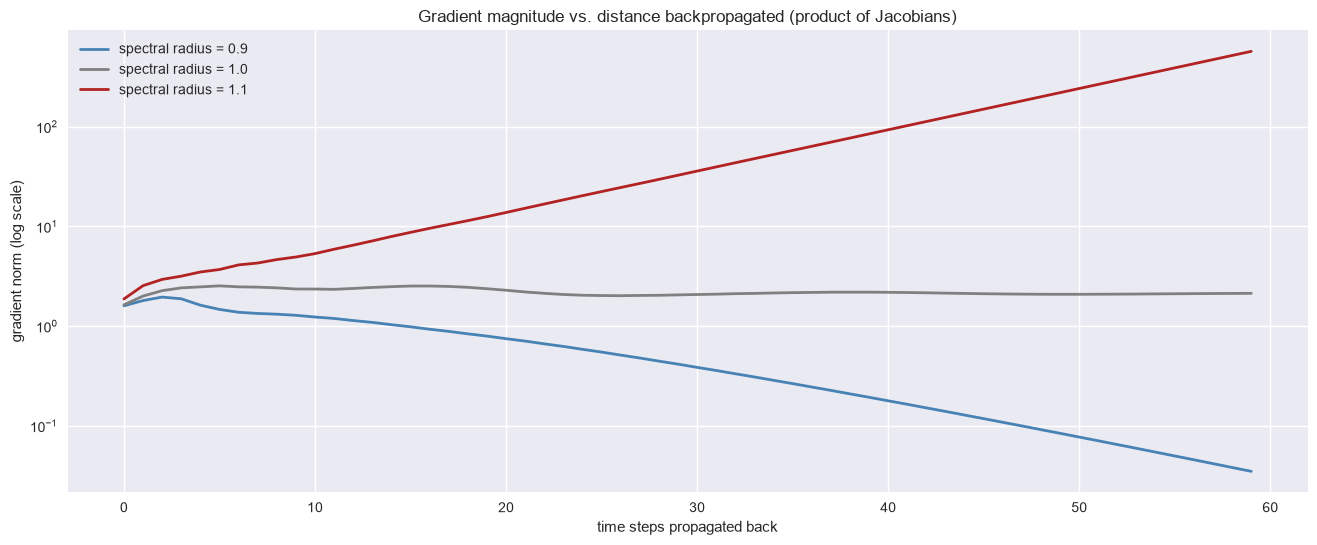

In [13]:
rng = np.random.default_rng(CFG.SEED)

STEPS = 60
for radius, color in [(0.9, 'steelblue'), (1.0, 'gray'), (1.1, 'firebrick')]:
    W = rng.normal(size=(32, 32))
    W = W * (radius / np.max(np.abs(np.linalg.eigvals(W))))  # rescale to target spectral radius
    prod = np.eye(32)
    norms = []
    for t in range(STEPS):
        prod = W @ prod                    # one more step of backpropagation through time
        norms.append(np.linalg.norm(prod, 2))
    plt.semilogy(norms, label=f'spectral radius = {radius}', color=color, linewidth=2)

plt.title('Gradient magnitude vs. distance backpropagated (product of Jacobians)')
plt.xlabel('time steps propagated back'); plt.ylabel('gradient norm (log scale)')
plt.legend(); plt.show()

The experiment: draw a random $32 \times 32$ matrix (the size of our future hidden layers), rescale it so its spectral radius is exactly 0.9, 1.0 or 1.1, and multiply it by itself sixty times — exactly what BPTT does to a gradient traveling back sixty steps — recording the matrix 2-norm as we go. The y-axis is logarithmic, so exponential behaviour appears as a straight line.

The picture is the whole vanishing-gradient literature in one chart. At $\rho = 0.9$ — a matrix only *slightly* contractive — the gradient's magnitude falls by nearly two orders of magnitude over sixty steps: whatever happened sixty days ago contributes a couple of percent of its original signal to the weight update, and in a real network the $\tanh$ derivative (always below 1) would shrink it much further. Push the horizon to a few hundred steps, or the radius a little lower, and the signal is effectively zero. At $\rho = 1.1$ the same sixty steps *amplify* the gradient by a factor of hundreds, en route to numerical overflow. The knife-edge $\rho = 1.0$ holds steady here — but it is exactly that, a knife-edge: nothing in gradient descent keeps a weight matrix pinned to spectral radius one, so a training run drifts into one failure regime or the other. Keep the blue line in mind: our `LOOK_BACK` is only 30 steps, comfortably within range, but this is exactly why plain RNNs are described as having a usable memory of a few dozen steps — and why asking one to connect events hundreds of steps apart is asking for the blue line's fate.

# RNN

Rung one: the simplest possible recurrent forecaster — one `SimpleRNN` layer implementing exactly the $h_t = \tanh(W_x x_t + W_h h_{t-1} + b)$ update from the groundwork section, and one `Dense` layer projecting the final hidden state onto a single number, tomorrow's scaled temperature.

## Single-layer RNN

In [14]:
def build_rnn():
    with keras.device(DEVICE):              # create weights (and thus train) on the accelerator
        model = Sequential([
            Input(shape=(CFG.LOOK_BACK, 1)),
            SimpleRNN(CFG.UNITS),
            Dense(1),
        ])
        model.compile(loss='mean_squared_error', optimizer='adam')
    return model

rnn = build_rnn()

The model is wrapped in a builder function — a habit worth copying, because it lets us reconstruct a fresh, untrained copy at any time (weights are randomly initialized anew on each call). The whole construction sits inside the **`with keras.device(DEVICE):`** block promised in Setup: the layer weights are created on the GPU, and since training happens where the weights live, the entire `fit` that follows runs there too. Inside, a `Sequential` model is literally a list of layers.

**`Input(shape=(CFG.LOOK_BACK, 1))`** declares what one sample looks like: 30 time steps, 1 feature. The batch dimension is never declared — Keras handles any batch size. (In modern Keras you declare inputs with this explicit `Input` layer rather than the legacy `input_shape=` argument on the first layer, which still works but earns a deprecation-style warning.)

**`SimpleRNN(CFG.UNITS)`** is the recurrence: a hidden state of 32 numbers, updated step by step across the 30 inputs. By default a recurrent layer in Keras returns *only the final* hidden state $h_{30}$ — a vector of 32 numbers summarizing the whole window — which is exactly what a "read the history, then predict" model wants.

**`Dense(1)`** is the read-out: one linear combination of those 32 numbers, producing the forecast. No activation function, because we are regressing a continuous (scaled) value, not classifying.

**`compile`** attaches the training objective: minimize **mean squared error** using **Adam**, the default optimizer of modern deep learning — a gradient descent variant that adapts the step size per parameter and needs essentially no tuning to work respectably.

In [15]:
rnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,121 (4.38 KB)

 Trainable params: 1,121 (4.38 KB)

 Non-trainable params: 0 (0.00 B)

`summary()` prints the architecture as a table, and the parameter count is worth decoding once. The `SimpleRNN` layer holds $32 \times 1$ input weights, $32 \times 32$ recurrent weights, and 32 biases: $32 + 1024 + 32 = 1{,}088$ parameters. The Dense read-out adds $32 + 1 = 33$. Total: 1,121 — compare that with the *two* parameters of the simple exponential smoother from the smoothing episode, and you see why neural networks need more data and a validation guardrail. The middle column shows the output shape of each layer: `(None, 32)` after the RNN (None = any batch size, 32 = the hidden state), `(None, 1)` after the Dense.

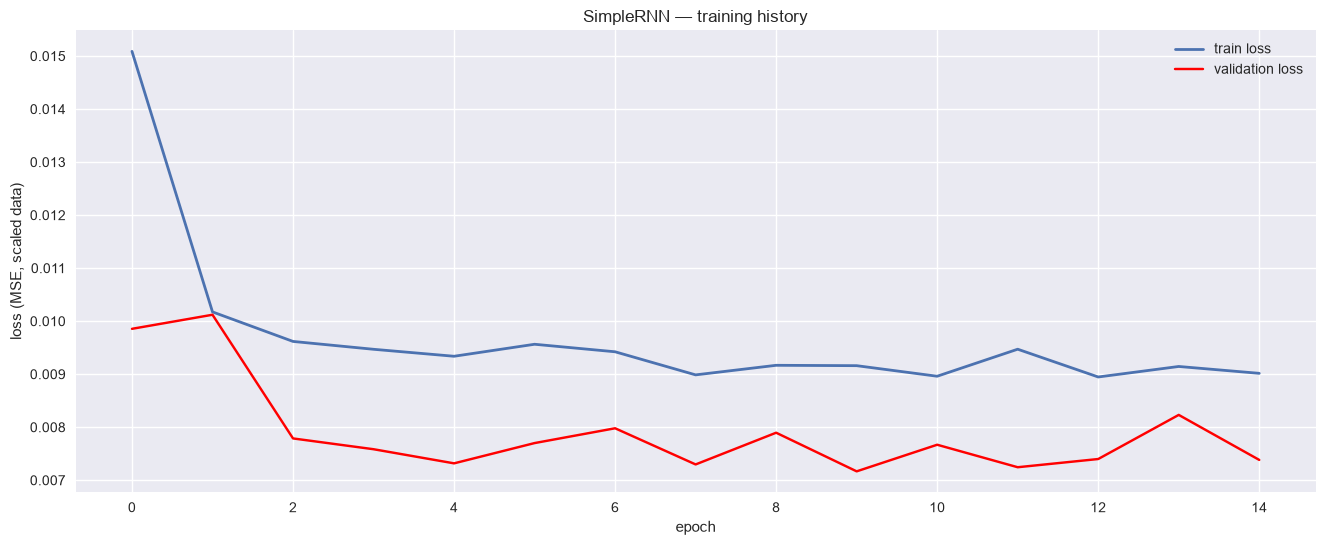

In [16]:
history = rnn.fit(
    X_train, y_train, validation_data=(X_valid, y_valid),
    epochs=CFG.EPOCHS, batch_size=CFG.BATCH_SIZE,
    callbacks=get_callbacks(), verbose=0,
)
plot_history(history, title='SimpleRNN — training history')

`fit` runs the training loop: each **epoch** is one full pass over the 2,890 training windows in batches of 32, i.e. about 90 gradient updates. `validation_data` makes Keras score the validation set after every epoch — those scores drive the early stopping callback, and it is worth being explicit about what the validation set is doing here: it *selects when to stop*, which means it participates (mildly) in model selection. In a production setting the final untouched judgement would come from a third, test segment, exactly as discussed in the validation episode; with one small dataset and a teaching goal, we accept the two-way split and keep the caveat in mind.

`verbose=0` suppresses the per-epoch progress bars (thirty of them would swamp the notebook); the `history` object returned by `fit` records both loss curves instead, and the plot tells the story at a glance: a steep drop in the first couple of epochs as the network learns the seasonal shape, then a long shallow tail with no widening train/validation gap, until early stopping calls it around the halfway mark. One quirk worth demystifying: the validation loss sits *below* the training loss, which looks backwards. Two boring reasons suffice — the training loss is averaged over the whole epoch (including its clumsy early batches) while validation is measured once, with the improved end-of-epoch weights; and these two particular validation years simply contain slightly tamer weather than the eight training ones. Neither is a red flag; a validation loss creeping *upwards* would be.

In [17]:
true = scaler.inverse_transform(y_valid)
pred = scaler.inverse_transform(rnn.predict(X_valid, verbose=0))

results['SimpleRNN'] = forecast_metrics(true, pred)
results['SimpleRNN']

{'MAE': 1.759, 'RMSE': 2.227}

Scoring, with one easy-to-forget step: the model lives in scaled space, so both its predictions and the validation targets go through **`scaler.inverse_transform`** to get back to degrees Celsius before the metrics are computed. Skip that, and you would be reporting errors on the $[0,1]$ scale — impressively tiny numbers, meaning nothing. The RMSE of 2.23 °C beats persistence (2.48 °C): the thirty-day window lets the network average out weather noise and lean on the seasonal position, which a one-day-memory forecast cannot do.

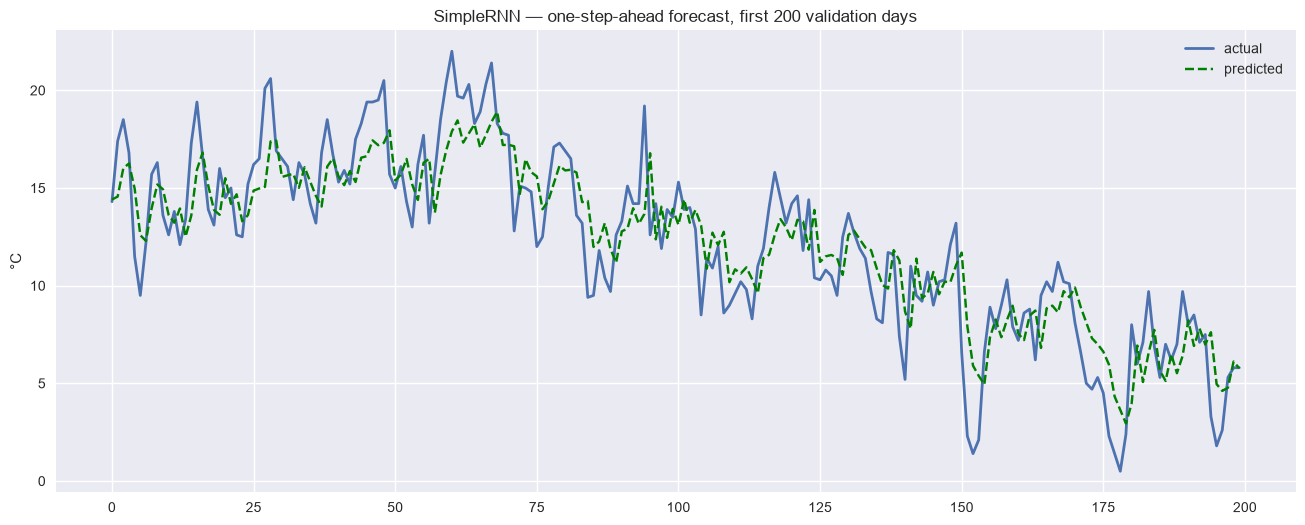

In [18]:
plot_forecast(true, pred, title='SimpleRNN — one-step-ahead forecast, first 200 validation days')

The overlay makes the numbers concrete. The prediction tracks the seasonal descent into the southern winter and the multi-day swings, but visibly *smooths* the series — the sharpest one-day spikes are undershot. That is not a flaw to fix; it is what minimizing squared error looks like when part of the variation is genuinely unpredictable: the model forecasts the conditional mean and lets the irreducible noise go.

## Stacked RNN

If one recurrent layer helps, do two help more? Stacking gives the network *depth in feature space* (the second layer operates on the first layer's hidden states, learning higher-level temporal patterns) on top of its depth in time.

In [19]:
def build_stacked_rnn():
    with keras.device(DEVICE):
        model = Sequential([
            Input(shape=(CFG.LOOK_BACK, 1)),
            SimpleRNN(CFG.UNITS, return_sequences=True),   # <- pass the WHOLE sequence down
            SimpleRNN(CFG.UNITS),
            Dense(1),
        ])
        model.compile(loss='mean_squared_error', optimizer='adam')
    return model

stacked = build_stacked_rnn()

history = stacked.fit(
    X_train, y_train, validation_data=(X_valid, y_valid),
    epochs=CFG.EPOCHS, batch_size=CFG.BATCH_SIZE,
    callbacks=get_callbacks(), verbose=0,
)
pred = scaler.inverse_transform(stacked.predict(X_valid, verbose=0))
results['Stacked RNN'] = forecast_metrics(true, pred)
results['Stacked RNN']

{'MAE': 1.768, 'RMSE': 2.246}

The new ingredient is **`return_sequences=True`** on the first layer, and it is the number-one gotcha of stacked recurrent models. By default a recurrent layer emits only its final state — shape `(batch, 32)` — but the layer above it is itself recurrent and needs *a sequence* to recurse over. `return_sequences=True` makes the first layer emit its hidden state at every step, shape `(batch, 30, 32)`, which the second layer consumes step by step. Forget the flag and you get the most famous error message in Keras RNN work: *expected ndim=3, found ndim=2*. The second layer keeps the default (final state only), because the Dense read-out wants a single vector.

Everything else — fit call, scoring, metrics — is identical to the single-layer version, which is deliberate: when only one thing changes in the code, any change in the score has one explanation. And the honest result is that there is no improvement to report: the stacked model lands at 2.25 °C RMSE, a hair *worse* than the single layer's 2.23 — a small dataset with one strong seasonal signal does not offer the extra layer anything new to find, so its extra parameters buy noise. Depth pays off on complex multivariate problems; on a univariate temperature series it mostly pays in parameters.

# GRU

Now the first of the two gated cures for the vanishing gradient we watched in NumPy. The **Gated Recurrent Unit** keeps the single hidden state $h_t$ but wraps its update in two learned valves, each a sigmoid function of the current input and previous state (so each gate is a vector of numbers between 0 and 1, one per hidden unit):

- the **reset gate** $r_t$ decides how much of the old state to consult when *proposing* new content: candidate $\tilde{h}_t = \tanh(W x_t + U (r_t \odot h_{t-1}))$;
- the **update gate** $z_t$ decides how much of the state to actually *overwrite*: $h_t = (1 - z_t) \odot h_{t-1} + z_t \odot \tilde{h}_t$.

That last equation is the cure, and it is worth staring at. The plain RNN *replaces* its state wholesale through a $\tanh$ at every step — sixty steps means sixty matrix multiplications between an early input and a late gradient, the geometric decay from our detour. The GRU state update is instead a **weighted average**: where the update gate sits near 0, the state (and, crucially, the gradient flowing back through it) passes essentially untouched — an *additive shortcut* through time rather than a multiplicative gauntlet. The gates are learned, so the network itself decides, dimension by dimension and step by step, what to preserve and what to rewrite.

In [20]:
def build_gru():
    with keras.device(DEVICE):
        model = Sequential([
            Input(shape=(CFG.LOOK_BACK, 1)),
            GRU(CFG.UNITS, return_sequences=True),
            GRU(CFG.UNITS),
            Dense(1),
        ])
        model.compile(loss='mean_squared_error', optimizer='adam')
    return model

gru = build_gru()

history = gru.fit(
    X_train, y_train, validation_data=(X_valid, y_valid),
    epochs=CFG.EPOCHS, batch_size=CFG.BATCH_SIZE,
    callbacks=get_callbacks(), verbose=0,
)
pred = scaler.inverse_transform(gru.predict(X_valid, verbose=0))
results['GRU'] = forecast_metrics(true, pred)
results['GRU']

{'MAE': 1.741, 'RMSE': 2.219}

The code is a diff of exactly one word — `SimpleRNN` became `GRU` — and that API symmetry is deliberate on Keras' part: same constructor, same `return_sequences` flag, same shapes. What changed is inside the cell: each GRU layer computes three transformations (reset gate, update gate, candidate) where the plain RNN computed one, so the parameter count roughly triples — 9,729 parameters against the stacked RNN's 3,201.

The score: 2.22 °C RMSE — ahead of both plain RNNs, but only by a nose. An honest reading, and a theme the deep learning forecasting literature keeps confirming: gating is about *long-range* credit assignment, and with a 30-step window over a strongly seasonal series there is only so much long range to assign. The gap grows with sequence length and problem complexity — and the point of this ladder is that when your problem does need 200 steps of memory, the fix is a one-word diff.

# LSTM

The second cure is older, bigger, and the most famous: the **Long Short-Term Memory** cell (Hochreiter & Schmidhuber, 1997). Where the GRU has one state and two gates, the LSTM splits memory into two parallel pathways:

- the **cell state** $c_t$ — a protected "memory highway" updated only by *element-wise scaling and addition*, never squashed through a $\tanh$ between steps;
- the **hidden state** $h_t$ — the working output, a gated, squashed read-out of the cell state.

Three sigmoid gates manage the traffic: the **forget gate** $f_t$ scales down old memory, the **input gate** $i_t$ admits new candidate content $g_t$, and the **output gate** $o_t$ decides how much of the memory is exposed as output:

$$c_t = f_t \odot c_{t-1} + i_t \odot g_t, \qquad h_t = o_t \odot \tanh(c_t)$$

The gradient of $c_t$ with respect to $c_{t-1}$ is (to leading order) just $f_t$ — no weight matrix, no activation derivative. Where the network learns to hold the forget gate near 1, gradients flow back across long gaps essentially undamped: the original papers call this the **constant error carousel**, and it is the additive-shortcut idea from the GRU section in its purest form. The price is the heaviest parameter bill of the family — four transformations per layer against the GRU's three and the plain RNN's one.

In [21]:
def build_lstm():
    with keras.device(DEVICE):
        model = Sequential([
            Input(shape=(CFG.LOOK_BACK, 1)),
            LSTM(CFG.UNITS, return_sequences=True),
            LSTM(CFG.UNITS),
            Dense(1),
        ])
        model.compile(loss='mean_squared_error', optimizer='adam')
    return model

lstm = build_lstm()

history = lstm.fit(
    X_train, y_train, validation_data=(X_valid, y_valid),
    epochs=CFG.EPOCHS, batch_size=CFG.BATCH_SIZE,
    callbacks=get_callbacks(), verbose=0,
)
pred = scaler.inverse_transform(lstm.predict(X_valid, verbose=0))
results['LSTM'] = forecast_metrics(true, pred)
results['LSTM']

{'MAE': 1.741, 'RMSE': 2.219}

Identical scaffolding once more, one-word diff, 12,705 parameters. The LSTM lands at 2.22 °C — matching the GRU to the third decimal on this run, and the two trade places freely under different seeds. On problems of this size, GRU and LSTM are near-interchangeable, and the practical folklore is worth recording: try the GRU first (fewer parameters, faster), reach for the LSTM when sequences are very long or the extra capacity of the separate cell state earns its keep. What you should *not* expect from either is a large win over well-configured simpler models on a short-window univariate task — the gates solve a memory problem, and you only get paid where the problem exists.

One inline formula for the road, since the parameter counts nicely summarize the whole family:

$$\text{RNN}: h \times (d + h + 1) \quad\big|\quad \text{GRU}: 3 \times [\,\cdot\,] \quad\big|\quad \text{LSTM}: 4 \times [\,\cdot\,]$$

one transformation, three, four — everything else is bookkeeping.

# Multi-step forecasting, three ways

Everything so far predicts a single day ahead. Real planning questions rarely stop there — and *how* you extend a one-step model to a horizon is a genuine modeling decision with its own failure modes. We will forecast `HORIZON = 14` days from each 30-day window, three ways:

1. **Recursive**: keep the one-step LSTM, feed each prediction back in as if it were an observation, repeat 14 times. This is exactly how ARIMA produced its multi-step forecasts. No new training — but every step consumes the previous step's *error* as input, so mistakes can compound along the horizon. How badly they compound turns out to depend on the series; we will measure it rather than assume it.
2. **Direct multi-output**: change the read-out to `Dense(14)` and train the network to emit the whole horizon in one forward pass. Errors no longer feed on each other — each of the 14 outputs is anchored to real observed inputs — at the cost of a fixed output length baked into the architecture.
3. **Encoder–decoder (seq2seq)**: the structured version of direct forecasting — one recurrent network *reads*, another *writes* — and the standard recommendation for long-horizon recurrent forecasting.

First, the data: same windowing helper, `look_ahead=14`. One subtlety in the split — a training window must now have its *entire 14-day target path* inside the training period, so the mask checks the last target day, not the first.

In [22]:
Xm, ym, tm = make_windows(scaled, look_back=CFG.LOOK_BACK, look_ahead=CFG.HORIZON)

m_train = tm + CFG.HORIZON - 1 < cutoff_idx   # whole target path before the boundary
m_valid = tm >= cutoff_idx                    # whole target path after it
Xm_train, ym_train = Xm[m_train], ym[m_train]
Xm_valid, ym_valid = Xm[m_valid], ym[m_valid]

ym_valid_deg = scaler.inverse_transform(ym_valid.reshape(-1, 1)).reshape(ym_valid.shape)
print(f'train {Xm_train.shape} {ym_train.shape} | valid {Xm_valid.shape} {ym_valid.shape}')

train (2877, 30, 1) (2877, 14) | valid (717, 30, 1) (717, 14)


Note the deliberate gap between the two masks: windows whose 14-day target path *straddles* the cutoff (starting in late December 1988, ending in January 1989) are dropped from both sets rather than assigned to either — the cheapest way to keep the boundary clean, at the cost of thirteen windows. This is the same "purging" idea met in the validation episode, in miniature. We also pre-compute `ym_valid_deg`, the validation target paths back in degrees Celsius: `inverse_transform` insists on a 2D column, hence the reshape round-trip.

In [23]:
# strategy 1: recursive — feed the one-step LSTM its own predictions
current = Xm_valid.copy()
rec = np.zeros_like(ym_valid)
for step in range(CFG.HORIZON):
    p = lstm.predict(current, verbose=0)                       # one step ahead...
    rec[:, step] = p[:, 0]
    current = np.concatenate([current[:, 1:, :],               # ...slide the window,
                              p.reshape(-1, 1, 1)], axis=1)    # append the prediction

rec_deg = scaler.inverse_transform(rec.reshape(-1, 1)).reshape(rec.shape)
results_ms = {'Recursive LSTM': forecast_metrics(ym_valid_deg.ravel(), rec_deg.ravel())}
results_ms['Recursive LSTM']

{'MAE': 2.135, 'RMSE': 2.754}

The recursive loop, vectorized over all 717 validation windows at once. Each iteration asks the already-trained one-step LSTM for its forecast, then manufactures the next input window by dropping the oldest day (`current[:, 1:, :]`) and appending the *prediction* in the newest slot — the model literally cannot tell it is now consuming its own output. After day one, the input window contains one fabricated value; by day fourteen, it contains fourteen. The overall RMSE across the full horizon, 2.75 °C, is the average of what will turn out to be a very lopsided per-step profile — hold that thought until the chart.

In [24]:
# strategy 2: direct multi-output — one forward pass emits all 14 days
with keras.device(DEVICE):
    direct = Sequential([
        Input(shape=(CFG.LOOK_BACK, 1)),
        LSTM(CFG.UNITS, return_sequences=True),
        LSTM(CFG.UNITS),
        Dense(CFG.HORIZON),                 # <- the only change: 14 outputs
    ])
    direct.compile(loss='mean_squared_error', optimizer='adam')

history = direct.fit(
    Xm_train, ym_train, validation_data=(Xm_valid, ym_valid),
    epochs=CFG.EPOCHS, batch_size=CFG.BATCH_SIZE,
    callbacks=get_callbacks(), verbose=0,
)
dir_pred = direct.predict(Xm_valid, verbose=0)
dir_deg = scaler.inverse_transform(dir_pred.reshape(-1, 1)).reshape(dir_pred.shape)
results_ms['Direct LSTM'] = forecast_metrics(ym_valid_deg.ravel(), dir_deg.ravel())
results_ms['Direct LSTM']

{'MAE': 2.165, 'RMSE': 2.792}

The direct strategy needs retraining (the target is now a 14-vector), but the architectural change is a single number: `Dense(CFG.HORIZON)`. The final hidden state is projected onto fourteen outputs simultaneously, and the MSE loss averages over all fourteen — during training, day 14 gets exactly as much gradient attention as day 1, and *every* output is conditioned on the same thirty real observations. No prediction is ever fed back in, so there is nothing to compound. This one-shot mapping of history onto a whole future path is something classical recursive forecasters structurally cannot do, and it is a large part of why neural approaches pull ahead of them as horizons grow, even when they lose at one step ahead.

In [25]:
# strategy 3: encoder-decoder (seq2seq)
with keras.device(DEVICE):
    seq2seq = Sequential([
        Input(shape=(CFG.LOOK_BACK, 1)),
        LSTM(CFG.UNITS),                          # ENCODER: history -> context vector
        RepeatVector(CFG.HORIZON),                # copy context once per future day
        LSTM(CFG.UNITS, return_sequences=True),   # DECODER: unroll over the horizon
        TimeDistributed(Dense(1)),                # shared read-out at every future step
    ])
    seq2seq.compile(loss='mean_squared_error', optimizer='adam')
seq2seq.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 32)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 14, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 14, 32)         │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 14, 1)          │            33 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,705 (49.63 KB)

 Trainable params: 12,705 (49.63 KB)

 Non-trainable params: 0 (0.00 B)

The encoder–decoder deserves its own `summary()`, because the layer stack reads like a diagram of the idea. The **encoder** LSTM consumes the 30-day window and — since `return_sequences` is left at its default — emits only its final hidden state: a 32-number **context vector**, the network's learned compression of everything relevant in the history. **`RepeatVector(14)`** copies that vector fourteen times, producing a `(batch, 14, 32)` tensor — one identical "briefing" per future day — because the decoder, being a recurrent layer, needs *something* of length 14 to recurse over. The **decoder** LSTM, with `return_sequences=True`, unrolls its own dynamics across those fourteen steps: unlike the direct model's Dense read-out, the decoder's day-9 state is computed from its day-8 state, so the *shape* of the forecast trajectory is itself modeled recurrently. Finally **`TimeDistributed(Dense(1))`** applies one shared 33-parameter read-out at every step — the same hidden-state-to-temperature conversion for day 1 and day 14, which is both parameter-efficient and sensible.

Why bother, when `Dense(14)` already works? On this problem, honestly, the direct model is competitive. The encoder–decoder earns its keep when input and output lengths differ wildly or vary, when the output has rich structure of its own, and as *the* template that scales up — attach the decoder to weather covariates, let it peek at known future inputs (holidays, promotions), or replace the repeated context vector with a learned attention over encoder states, and you have rebuilt the architectures behind modern sequence models. It is the last rung of this ladder and the first rung of the next one.

In [26]:
history = seq2seq.fit(
    Xm_train, ym_train.reshape(-1, CFG.HORIZON, 1),
    validation_data=(Xm_valid, ym_valid.reshape(-1, CFG.HORIZON, 1)),
    epochs=CFG.EPOCHS, batch_size=CFG.BATCH_SIZE,
    callbacks=get_callbacks(), verbose=0,
)
s2s_pred = seq2seq.predict(Xm_valid, verbose=0)[:, :, 0]
s2s_deg = scaler.inverse_transform(s2s_pred.reshape(-1, 1)).reshape(s2s_pred.shape)
results_ms['Seq2seq LSTM'] = forecast_metrics(ym_valid_deg.ravel(), s2s_deg.ravel())

pd.DataFrame(results_ms).T

,MAE,RMSE
Recursive LSTM,2.135,2.754
Direct LSTM,2.165,2.792
Seq2seq LSTM,2.148,2.771


One shape adjustment on both ends: `TimeDistributed(Dense(1))` outputs `(batch, 14, 1)`, so the targets are reshaped to match for training, and the trailing singleton axis is sliced off the predictions (`[:, :, 0]`) for scoring. The interim table shows the overall 14-day averages side by side — but averages over a horizon hide exactly the thing this section is about, so the next chart splits the error by lead time.

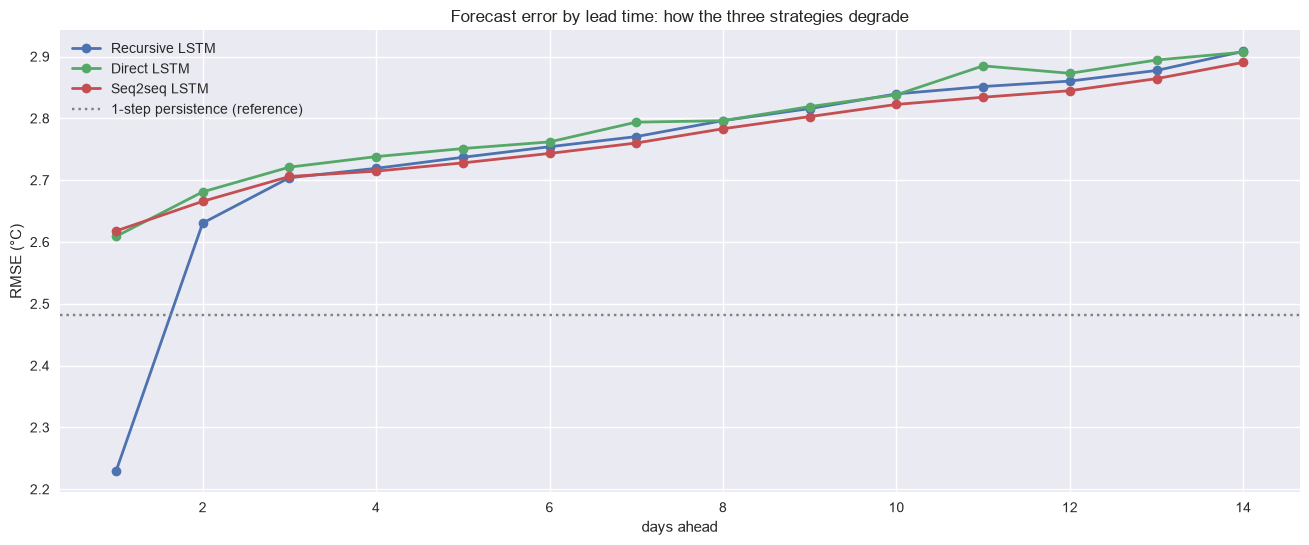

In [27]:
def per_step_rmse(pred_deg):
    return [float(np.sqrt(mean_squared_error(ym_valid_deg[:, s], pred_deg[:, s])))
            for s in range(CFG.HORIZON)]

steps = np.arange(1, CFG.HORIZON + 1)
plt.plot(steps, per_step_rmse(rec_deg), marker='o', linewidth=2, label='Recursive LSTM')
plt.plot(steps, per_step_rmse(dir_deg), marker='o', linewidth=2, label='Direct LSTM')
plt.plot(steps, per_step_rmse(s2s_deg), marker='o', linewidth=2, label='Seq2seq LSTM')
plt.axhline(results['Persistence (t-1)']['RMSE'], color='gray', linestyle=':',
            label='1-step persistence (reference)')
plt.title('Forecast error by lead time: how the three strategies degrade')
plt.xlabel('days ahead'); plt.ylabel('RMSE (°C)')
plt.legend(); plt.show()

This chart is the payoff of the whole section, and it rewards a careful read — it does *not* show the cartoon version of the story. Three observations, in order of how much they should surprise you.

First, the recursive curve starts far below the others: 2.23 °C at day 1 (it *is* the one-step LSTM, scored on its specialty) versus about 2.6 °C for the direct and seq2seq models. That is the hidden price of multi-output training: the loss averages all fourteen days, so the model trades away day-1 sharpness to serve the whole horizon. If you mostly care about tomorrow, the specialist wins — by a lot.

Second, the compounding we predicted for the recursive strategy is real but *self-limiting* here: the blue curve climbs steeply for two days, joins the pack by day 3, and thereafter all three strategies ride the same slow drift to about 2.9 °C. Why no runaway? Because temperature is strongly **mean-reverting**: fed its own outputs, the LSTM's forecast relaxes toward the seasonal average — and "the seasonal average" happens to be a very sensible 14-day forecast. Errors compound viciously when a series *trends* (each fabricated input walks the forecast further off the path); on a series that pulls everything back to a seasonal level, recursion is forgiven. This is exactly the regime the forecasting-competition literature maps out: recursive statistical methods rule short horizons, multi-output deep models pull ahead as horizons stretch and dynamics get less forgiving — up to high single-digit percentage gains at long leads.

Third, the ceiling itself: by day 5 or so, every strategy's error exceeds what naive persistence achieves at day 1 (the dotted line), and the curves flatten near 2.9 °C — which is essentially the error of forecasting the seasonal climate and accepting the weather. Two weeks out, *what day it is* carries more information than anything in the last thirty days of observations. No architecture in this notebook can beat that; it is the irreducible noise floor of the problem, and recognizing such a floor is as much a forecasting skill as lowering it.

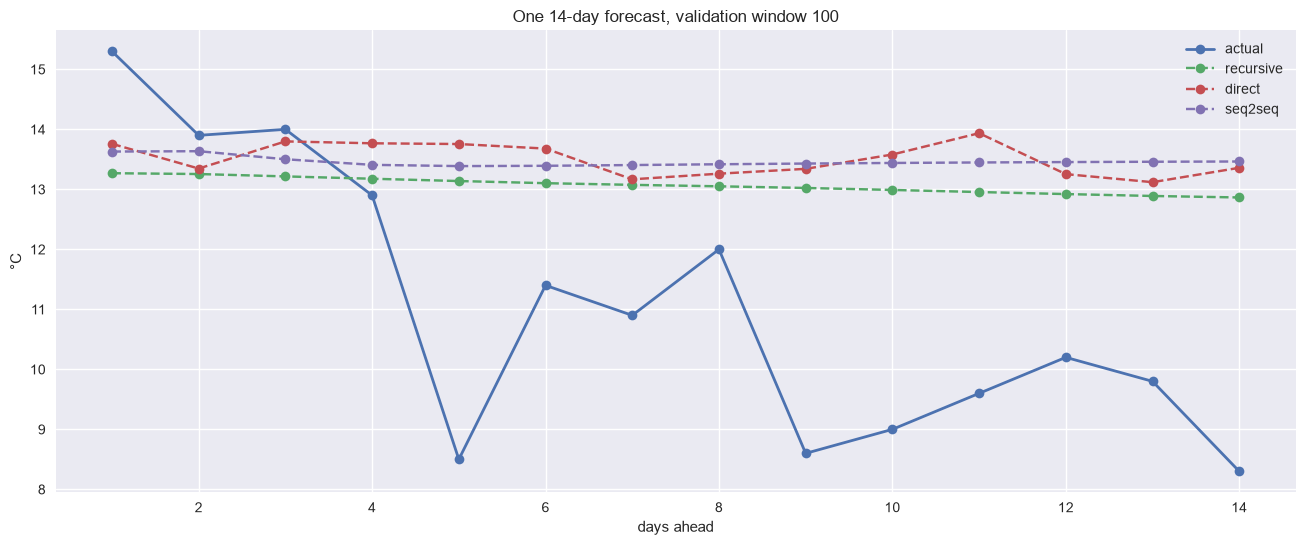

In [28]:
sample = 100
plt.plot(steps, ym_valid_deg[sample], linewidth=2, marker='o', label='actual')
plt.plot(steps, rec_deg[sample], linestyle='--', marker='o', label='recursive')
plt.plot(steps, dir_deg[sample], linestyle='--', marker='o', label='direct')
plt.plot(steps, s2s_deg[sample], linestyle='--', marker='o', label='seq2seq')
plt.title(f'One 14-day forecast, validation window {sample}')
plt.xlabel('days ahead'); plt.ylabel('°C'); plt.legend(); plt.show()

And one concrete trajectory, to keep the aggregate honest: a single validation window and its three competing 14-day paths against what actually happened. Window 100 is instructive precisely because the models *miss*: all three forecasts sit in a calm band around 13 °C — near the seasonal level implied by the input window — while the actual temperature takes a cold detour down to 8 °C. None of them foresees it, and none of them should be expected to: a cold snap five days out is weather, not climate, and a squared-error-minimizing forecast correctly declines to gamble on it. This is what the conditional-mean effect from the one-step section looks like stretched over a horizon — smooth, central, and unbothered — and it is a preview of why the next episode in any forecasting curriculum after point forecasts is *probabilistic* forecasting: the interesting object here is not the line but the uncertainty band that should have surrounded it. Individual windows vary a lot (pick another `sample` and look); the per-step RMSE chart above is the average over 717 of these.

# Going multivariate: covariates and a bidirectional LSTM

Two ingredients remain. First, **covariates**: nothing about the `[batch, timesteps, features]` tensor says `features` must equal 1 — the network can watch several signals evolve in parallel and learn their interactions. Second, the **`Bidirectional`** wrapper, which reads each window both forwards and backwards.

That second ingredient comes with the sharpest safety warning of the episode. A bidirectional layer's backward pass consumes the *end* of its input sequence first — so if the sequence extends into the future relative to the prediction target, the model is reading tomorrow to predict today. In sequence *classification* (is this heartbeat arrhythmic? when will this machine fail, given its full sensor log?) the whole sequence is legitimately available and bidirectionality shines. In *forecasting*, it is safe only when the input window lies entirely in the past — which ours does: we read thirty *historical* days in both directions, and looking at Tuesday-through-Monday backwards breaks no laws of physics. The trap is subtle pipeline errors — windows built before splitting, targets inside the window's time span — where a bidirectional model will happily exploit the leak and reward you with beautiful validation scores that evaporate in production. Empirical audits of leaky setups have measured performance overstated by double-digit percentages. Rule of thumb: bidirectional layers amplify whatever your pipeline does — including its mistakes.

In [29]:
feat = df.copy()

# rolling averages of the recent past (shift(1) so they never include 'today')
feat['roll_mean_7'] = feat['Temp'].shift(1).rolling(7).mean()
feat['roll_mean_30'] = feat['Temp'].shift(1).rolling(30).mean()

# calendar position encoded as a smooth cycle
doy = feat.index.dayofyear
feat['doy_sin'] = np.sin(2 * np.pi * doy / 365.25)
feat['doy_cos'] = np.cos(2 * np.pi * doy / 365.25)

feat = feat.dropna()
feat.head(3)

,Temp,roll_mean_7,roll_mean_30,doy_sin,doy_cos
Date,,,,,
1981-01-31,15.4,16.914286,17.790000,0.508356,0.861147
1981-02-01,15.3,16.828571,17.613333,0.523094,0.852275
1981-02-02,18.8,16.657143,17.526667,0.537677,0.843151


Four covariates join the temperature, each with a reason. The **rolling means** (7- and 30-day) hand the network pre-digested summaries of the recent level; note **`.shift(1)`** *before* `.rolling()` — the 7-day mean available on day $t$ is computed from days $t-7 \dots t-1$, never including day $t$ itself. The feature must be computable at prediction time, a rule worth applying mechanically to every engineered feature. The **day-of-year sine/cosine pair** encodes calendar position as coordinates on a circle, fixing two problems at once: the raw day number has a fake cliff (December 31 = 365 is numerically far from January 1 = 1, though they are neighbors), and a single sine cannot distinguish spring from autumn (same value, crossing in opposite directions) — the cosine breaks the tie. This tells the network *where in the season it is* directly, rather than forcing it to infer that from the shape of the window. `dropna()` removes the first thirty rows, where the rolling means have no history to average.

In [30]:
feature_cols = ['Temp', 'roll_mean_7', 'roll_mean_30', 'doy_sin', 'doy_cos']
cut_feat = cutoff_idx - (len(df) - len(feat))       # same date boundary, shifted index

# scaler for the input matrix and a separate one to un-scale predictions
scaler_X = MinMaxScaler().fit(feat[feature_cols].iloc[:cut_feat])
scaler_y = MinMaxScaler().fit(feat[['Temp']].iloc[:cut_feat])

Xf, yf, tf_idx = make_windows(scaler_X.transform(feat[feature_cols]),
                              look_back=CFG.LOOK_BACK, look_ahead=1, target_col=0)

f_train = tf_idx < cut_feat
Xf_train, yf_train = Xf[f_train], yf[f_train]
Xf_valid, yf_valid = Xf[~f_train], yf[~f_train]
print(f'train {Xf_train.shape} | valid {Xf_valid.shape}')

train (2860, 30, 5) | valid (730, 30, 5)


The same discipline, multivariate edition. `dropna` shortened the frame by thirty rows, so the cutoff index shifts by the same amount to keep the *date* boundary at 1 January 1989. Two scalers appear: **`scaler_X`** rescales the full five-column feature matrix (MinMaxScaler works column by column, each feature getting its own min and max — both fitted on training rows only), while **`scaler_y`** exists solely to translate predictions back into degrees. Since `Temp` is column 0 of the feature matrix and MinMax scaling is per-column, the target windows extracted by `target_col=0` are on exactly the scale `scaler_y` inverts.

`make_windows` — unchanged, as promised — now returns `X` of shape `(windows, 30, 5)`: each training example is a thirty-day *matrix* of five signals. That third tensor dimension is the entire API cost of going multivariate.

In [31]:
with keras.device(DEVICE):
    bilstm = Sequential([
        Input(shape=(CFG.LOOK_BACK, len(feature_cols))),
        Bidirectional(LSTM(CFG.UNITS, return_sequences=True)),
        Bidirectional(LSTM(16)),
        Dense(1),
    ])
    bilstm.compile(loss='mean_squared_error', optimizer='adam')
bilstm.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 30, 64)         │         9,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 32)             │        10,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,129 (78.63 KB)

 Trainable params: 20,129 (78.63 KB)

 Non-trainable params: 0 (0.00 B)

**`Bidirectional`** is a wrapper, not a layer type: you hand it any recurrent layer and it builds two copies — one reading the window January-to-December, one December-to-January — and concatenates their outputs, so a wrapped `LSTM(32)` emits 64 numbers per step (the summary's output shapes show the doubling, and the parameter count doubles likewise). For a forecasting read of a historical window, the backward pass gives the network a second perspective in which the *most recent* days are processed first, unweathered by thirty steps of state updates. The second wrapped layer is narrower (16 units) — a common funnel pattern — and everything funnels into the same `Dense(1)` read-out as ever.

In [32]:
history = bilstm.fit(
    Xf_train, yf_train, validation_data=(Xf_valid, yf_valid),
    epochs=CFG.EPOCHS, batch_size=CFG.BATCH_SIZE,
    callbacks=get_callbacks(), verbose=0,
)
pred_bi = scaler_y.inverse_transform(bilstm.predict(Xf_valid, verbose=0))
true_bi = scaler_y.inverse_transform(yf_valid)

results['BiLSTM + covariates'] = forecast_metrics(true_bi, pred_bi)
results['BiLSTM + covariates']

{'MAE': 1.73, 'RMSE': 2.195}

Same training loop, same early stopping, and predictions inverted through **`scaler_y`** — inverting through the five-column `scaler_X` would fail (wrong shape) and make no sense anyway. (The rolling-mean warm-up cost thirty windows, all of them at the *training* end of the data; the validation set is the same 730 days as before, so the scores remain directly comparable.) Result: 2.20 °C RMSE — the best score in the notebook. The margin over the plain LSTM is real but modest, and its anatomy is worth stating: the rolling means largely duplicate information the thirty-day window already carries, so the genuinely new signal is the day-of-year encoding — handing the model its seasonal position directly instead of making it infer that from the window's shape. Covariates earn their keep in proportion to how much *outside* information they inject; on richer problems (prices, promotions, holidays, sensors) this is where the large gains live.

# The verdict

In [33]:
comparison = pd.DataFrame(results).T.sort_values('RMSE')
comparison

,MAE,RMSE
BiLSTM + covariates,1.730,2.195
GRU,1.741,2.219
LSTM,1.741,2.219
SimpleRNN,1.759,2.227
Stacked RNN,1.768,2.246
Persistence (t-1),1.953,2.481
Seasonal naive (t-365),2.965,3.728


The one-step-ahead scoreboard, sorted best-first. The reading:

**Every network cleared the persistence bar** (2.48 °C) — not a given, and the first thing to check in any deep learning forecasting exercise. The seasonal naive trails far behind everything, confirming that last year's specific weather is a poor forecast even when the seasonal *shape* is strong.

**The spread across architectures is modest.** Five neural models span 2.20 to 2.25 °C RMSE — a two-percent band — while the step from persistence down to *any* of them is more than ten times that. This is the honest shape of the field on a small univariate series with a dominant seasonal cycle: the window already contains most of what is knowable, and the architectures differ mainly in how gracefully they extract it. The decisive contrasts in this notebook were never between cell types — they were between *task framings* (the one-step specialist beat the multi-output models by 0.4 °C on day-1 error, while the horizon's noise floor swallowed everyone by day 5) and between *pipelines* (a leaked scaler would have flattered every number here).

Which is the setting where each tool actually wins: gates when dependencies are long, covariates when the outside world matters, encoder–decoders when the horizon is long, and — as the validation and competition literature keeps repeating — classical statistical baselines whenever series are short, sparse, and numerous. Deep learning earns its complexity budget through **global training** (one network across thousands of related series, sharing patterns the way one shop's demand informs another's), through raw covariates classical models cannot ingest, and through direct multi-horizon output. None of those levers exist on a single temperature series — and it still took a fair fight with persistence to stay ahead.

# Conclusion

The ladder, climbed: a NumPy experiment that made the vanishing gradient visible, a plain RNN that beat persistence, gated cells that matched it with better long-range mechanics, three multi-step strategies with visibly different error-compounding behaviour, and a multivariate bidirectional finale.

Four mental models to keep:

1. **Windowing is the bridge.** Deep learning forecasting is supervised learning on sliding windows shaped `[batch, timesteps, features]`. Once you can produce that tensor (and split it by *target date*, scaler fitted on the past only), every architecture in this notebook is a drop-in.
2. **Memory is a gradient-flow problem.** Plain RNNs forget because products of Jacobians decay geometrically ($\rho < 1$) or explode ($\rho > 1$). GRU and LSTM fix it the same way: an additive, gate-protected path through time that lets both information and gradients travel far. That is the entire conceptual content of the gate equations.
3. **The multi-step strategy matters as much as the cell — and the data decides which one wins.** Recursive forecasting compounds its own errors but keeps day-1 sharpness; direct and encoder–decoder models spend their error budget evenly across the horizon at the cost of the early steps. On our mean-reverting temperatures the compounding was self-limiting and the specialist held its own; on trending or drifting series it is not so forgiving. Don't assume — draw the per-step error curve and let it choose.
4. **Bidirectionality is a scalpel.** Legitimate when the whole input sequence is truly available at prediction time; a leak amplifier when it is not.

Where next from here: the encoder–decoder built above is one attention layer away from the Transformer, and the ideas transfer almost verbatim — attention replaces the fixed context vector with a learned, per-output-step weighting over the encoder's states. The modern forecasting-specific architectures (N-BEATS, N-HiTS, Temporal Fusion Transformer) and the global-model libraries that wrap them (`darts`, `neuralforecast`) all build on exactly the primitives this notebook assembled by hand: windows, gates, encoders, decoders — plus the discipline of clean chronological validation, which no architecture will ever supply for you.